## Two Moon Problem Setup

**1. Prior Sampling:**
- The prior is uniform over $[-1, 1]^2$. 

**2. Two Moons Simulator:**
- The simulator follows the equations provided:
    - $a \sim U(-\pi/2, \pi/2)$ : Random angle
    - $ r \sim N(0.1, 0.01^2)$ : Random radius with Gaussian noise
    - p is computed based on a and r, forming the crescent
      $$
      p = (r cos(a) + 0.25, r sin(a))
      $$

    - shift is applied using the parameter $\theta = [\theta_1, \theta_2]$
      $$
      x = p + \left(\frac{|\theta_1 + \theta_2|}{\sqrt{2}}, \frac{-\theta_1 + \theta_2}{\sqrt{2}} \right)
      $$

**3. True observation:**
$observation = [0,0]$




 



### SBI 

In [1]:
import os
import sys
import timeit

# Add the parent directory (lfi) to sys.path
sys.path.insert(0, os.path.abspath('..'))
import sbi
import sbi.utils
import sbi.inference
import sbi.diagnostics
import sbi.analysis
import lfi
import torch
import numpy as np
from lfi import utils
from lfi import priors, simulators

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
import lfi.inference.from_sbi

### Budget: 10_000

In [11]:
np.random.seed(21355)
torch.manual_seed(21)

In [12]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [13]:
inference = lfi.inference.from_sbi.FMPESingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [14]:
samples, time = inference.fit_and_sample(budget=10000, num_samples=100)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 72 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Sampling time: 23.61 seconds


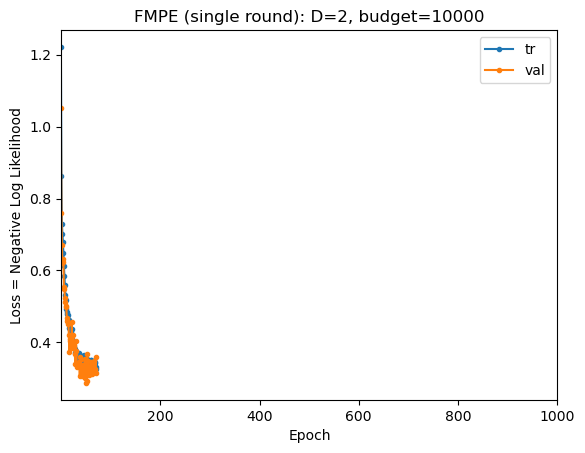

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'FMPE (single round): D=2, budget=10000'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [15]:
inference.plot_training_summary(budget=10000)

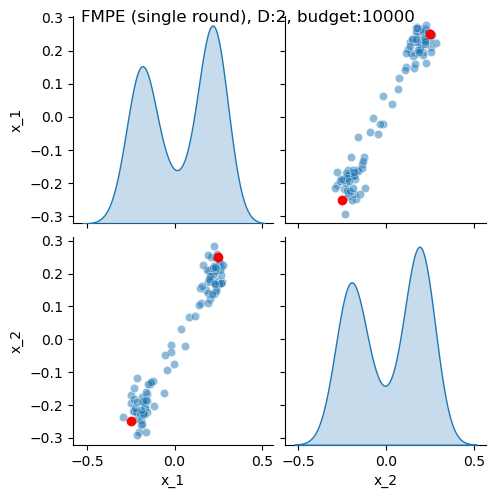

In [16]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=10000,
    posterior_modes=posterior_modes,
    subset_dims = [d for d in range(D)],
)

### budget 50_000

In [17]:
np.random.seed(21355)
torch.manual_seed(21)

In [18]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [19]:
inference = lfi.inference.from_sbi.FMPESingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [20]:
samples, time = inference.fit_and_sample(budget=50_000, num_samples=100)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 59 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Sampling time: 99.77 seconds


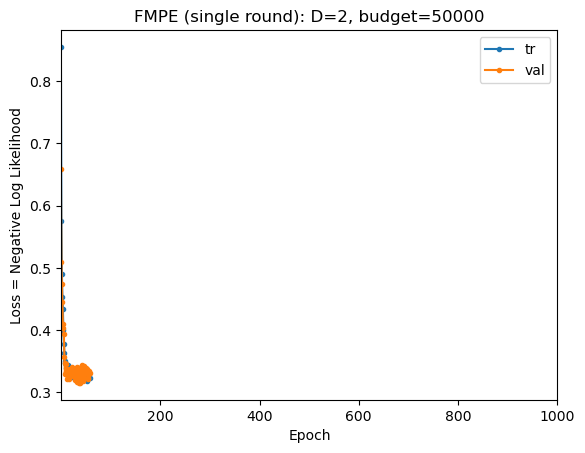

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'FMPE (single round): D=2, budget=50000'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [21]:
inference.plot_training_summary(budget=50000)

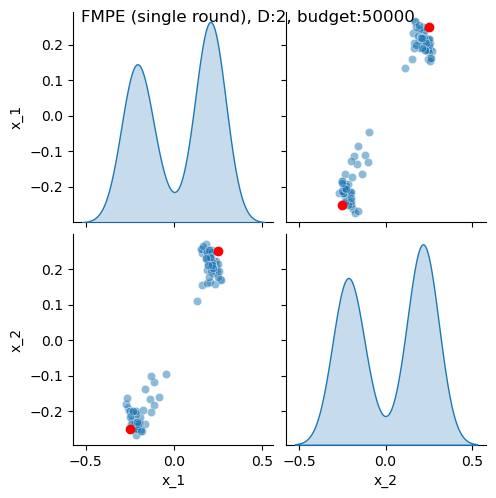

In [22]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=50000,
    posterior_modes=posterior_modes,
    subset_dims = [d for d in range(D)],
)

### budget=100_000

In [23]:
np.random.seed(21355)
torch.manual_seed(21)

In [24]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [25]:
inference = lfi.inference.from_sbi.FMPESingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [26]:
samples, time = inference.fit_and_sample(budget=100_000, num_samples=100)

  0%|          | 0/100000 [00:00<?, ?it/s]

 Neural network successfully converged after 59 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Sampling time: 202.30 seconds


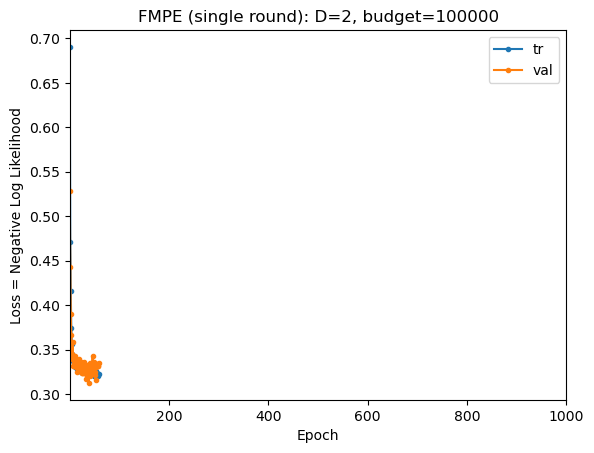

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'FMPE (single round): D=2, budget=100000'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [27]:
inference.plot_training_summary(budget=100_000)

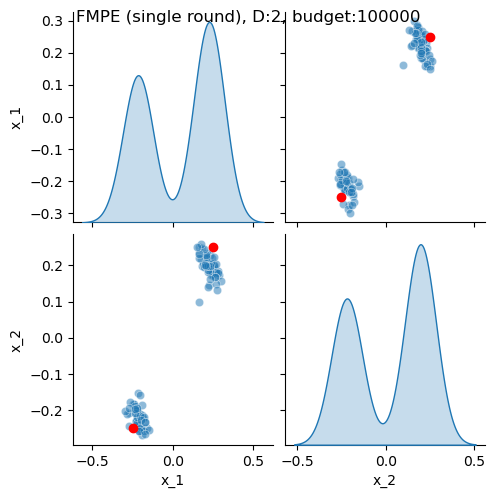

In [28]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=100000,
    posterior_modes=posterior_modes,
    subset_dims = [d for d in range(D)],
)

## NPE_A algorithm

### budget: 10_000

In [30]:
np.random.seed(21355)
torch.manual_seed(21)

In [31]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [32]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [33]:
samples, time = inference.fit_and_sample(budget=10000, num_samples=100)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 179 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Sampling time: 54.51 seconds


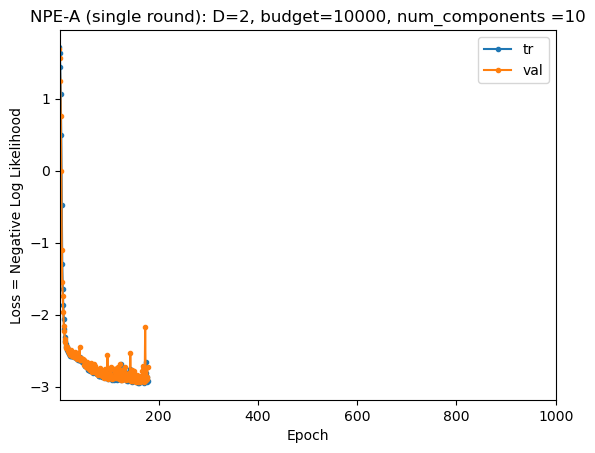

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'NPE-A (single round): D=2, budget=10000, num_components =10'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [34]:
inference.plot_training_summary(budget=10000, num_components=10)

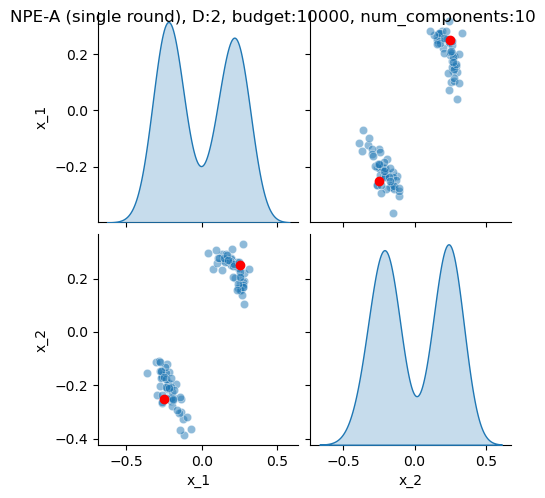

In [35]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=10_000,
    posterior_modes=posterior_modes,
    subset_dims=[d for d in range(D)],
    num_components = 10,
)

### bydget: 50_000

In [36]:
np.random.seed(21355)
torch.manual_seed(21)

In [37]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [38]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [39]:
samples, time = inference.fit_and_sample(budget=50000, num_samples=100)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 103 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Sampling time: 161.19 seconds


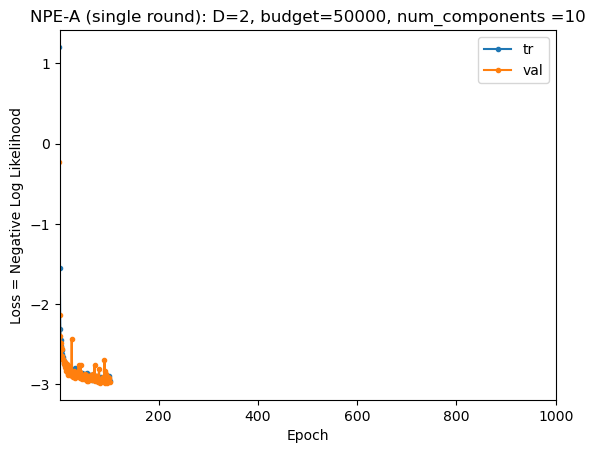

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'NPE-A (single round): D=2, budget=50000, num_components =10'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [40]:
inference.plot_training_summary(budget=50000, num_components=10)

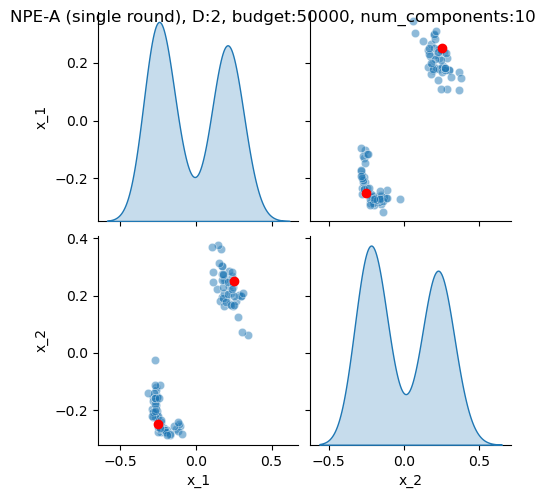

In [41]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=50_000,
    posterior_modes=posterior_modes,
    subset_dims=[d for d in range(D)],
    num_components = 10,
)

### budget: 100_000

In [42]:
np.random.seed(21355)
torch.manual_seed(21)

In [43]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [44]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [45]:
samples, time = inference.fit_and_sample(budget=100_000, num_samples=100)

  0%|          | 0/100000 [00:00<?, ?it/s]

 Neural network successfully converged after 85 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Sampling time: 262.04 seconds


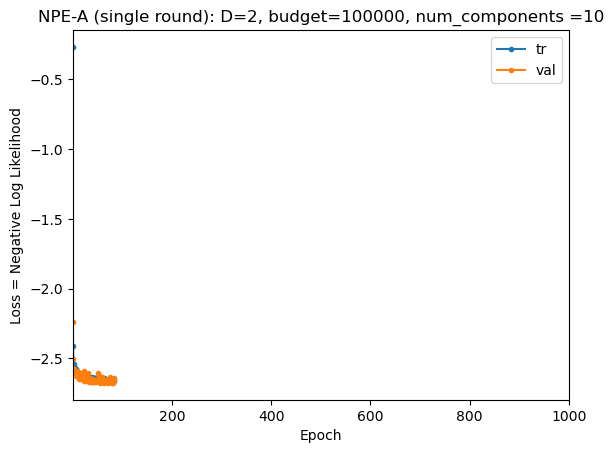

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'NPE-A (single round): D=2, budget=100000, num_components =10'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [46]:
inference.plot_training_summary(budget=100_000, num_components=10)

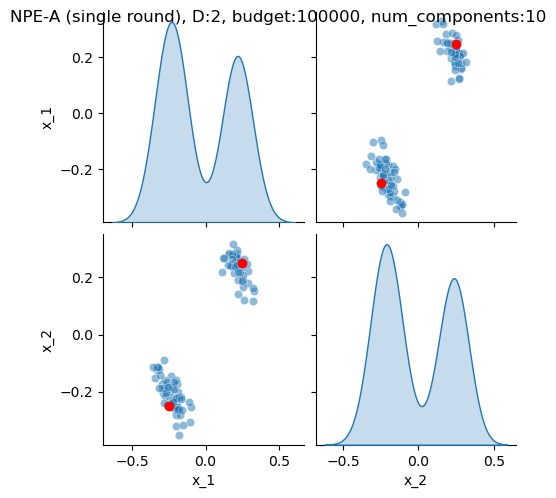

In [47]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=100_000,
    posterior_modes=posterior_modes,
    subset_dims=[d for d in range(D)],
    num_components = 10,
)

## NPE_C Algorithm

### budget: 5_000

In [70]:
np.random.seed(21355)
torch.manual_seed(21)

In [71]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [72]:
density_estimator_fun = sbi.neural_nets.posterior_nn(
    model='nsf',
    hidden_features=100,# 20, # 50,
    num_transforms=8,# 2, # 5,
    z_score_x="independent",
    z_score_theta="independent",
)

In [73]:
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [74]:
samples, time = inference.fit_and_sample(budget=5_000, num_samples=100, density_estimator=density_estimator_fun)

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 109 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Samling time: 104.65 seconds


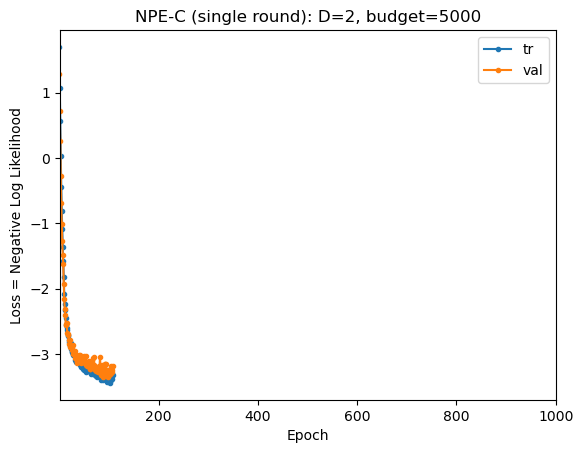

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'NPE-C (single round): D=2, budget=5000'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [75]:
inference.plot_training_summary(budget=5_000)

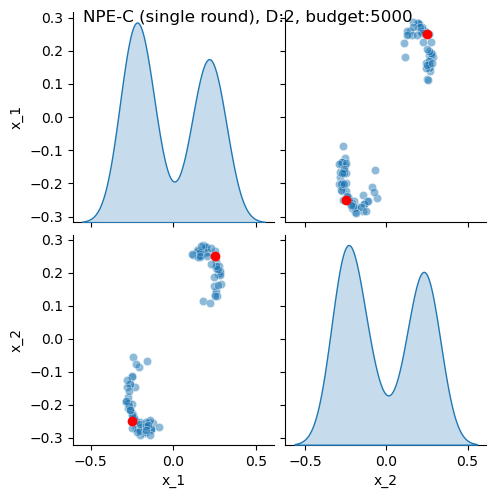

In [76]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=5_000,
    posterior_modes=posterior_modes,
    subset_dims=[d for d in range(D)],
)

### budget: 10_000

In [56]:
np.random.seed(21355)
torch.manual_seed(21)

In [57]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [58]:
density_estimator_fun = sbi.neural_nets.posterior_nn(
    model='nsf',
    hidden_features=100,# 20, # 50,
    num_transforms=8,# 2, # 5,
    z_score_x="independent",
    z_score_theta="independent",
)

In [59]:
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [60]:
samples, time = inference.fit_and_sample(budget=10_000, num_samples=100, density_estimator=density_estimator_fun)

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 108 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Samling time: 205.59 seconds


C:\Users\Theodora\anaconda3\envs\pytorch2\lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\BatchLinearAlgebra.cpp:2198.)
  outputs, _ = torch.triangular_solve(


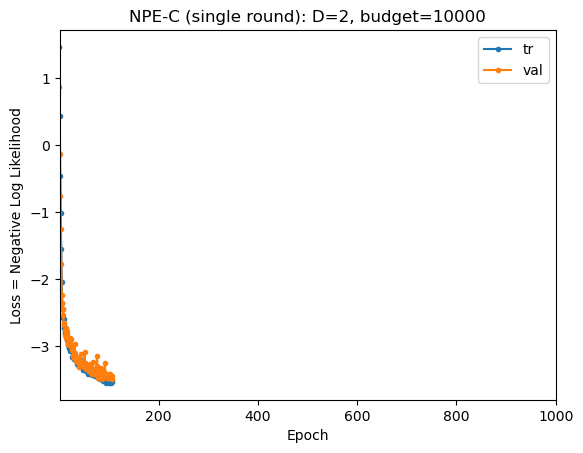

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'NPE-C (single round): D=2, budget=10000'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [61]:
inference.plot_training_summary(budget=10_000)

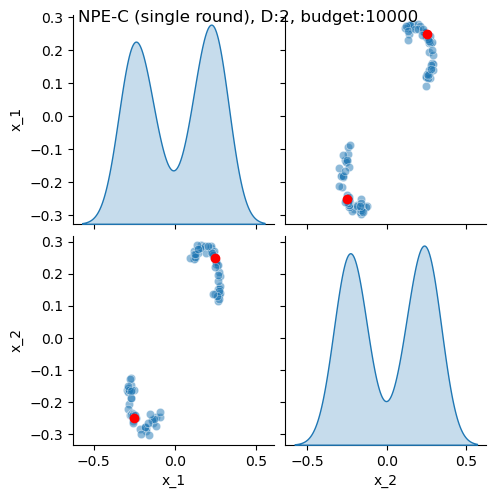

In [62]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=10_000,
    posterior_modes=posterior_modes,
    subset_dims=[d for d in range(D)],
)

### budget: 50_000

In [63]:
np.random.seed(21355)
torch.manual_seed(21)

In [64]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [65]:
density_estimator_fun = sbi.neural_nets.posterior_nn(
    model='nsf',
    hidden_features=100,# 20, # 50,
    num_transforms=8,# 2, # 5,
    z_score_x="independent",
    z_score_theta="independent",
)

In [66]:
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [67]:
samples, time = inference.fit_and_sample(budget=50_000, num_samples=100, density_estimator=density_estimator_fun)

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 144 epochs.

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]


Training/Samling time: 1344.75 seconds


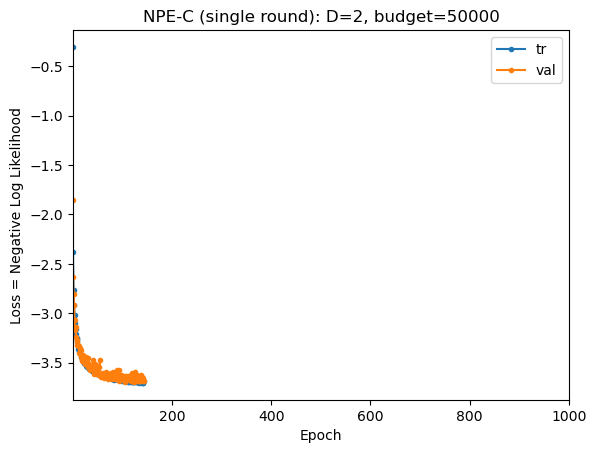

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'NPE-C (single round): D=2, budget=50000'}, xlabel='Epoch', ylabel='Loss = Negative Log Likelihood'>)

In [68]:
inference.plot_training_summary(budget=50_000)

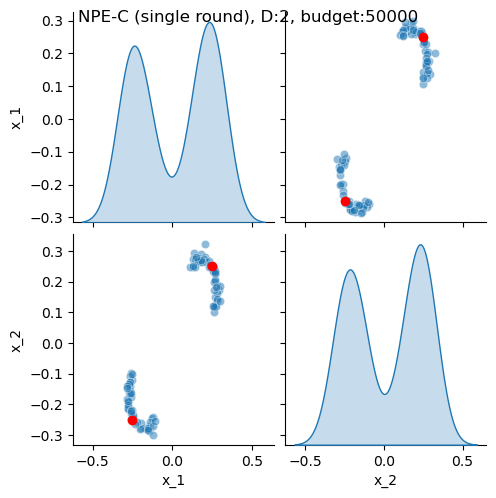

In [69]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=50_000,
    posterior_modes=posterior_modes,
    subset_dims=[d for d in range(D)],
)

### budget: 100_000

In [ ]:
np.random.seed(21355)
torch.manual_seed(21)

In [ ]:
D = 2
subset_dims = [i for i in range(D)]
limits=[-2,2]
prior = lfi.priors.UniformPrior(low = -1, high = 1, dim=D)
sim = lfi.simulators.TwoMoon()
observation = np.zeros((1, D))
posterior_modes = np.ones((2,D))
posterior_modes[0, :] = -0.25
posterior_modes[1, :] = 0.25

In [ ]:
density_estimator_fun = sbi.neural_nets.posterior_nn(
    model='nsf',
    hidden_features=100,# 20, # 50,
    num_transforms=8,# 2, # 5,
    z_score_x="independent",
    z_score_theta="independent",
)

In [ ]:
inference = lfi.inference.from_sbi.NPECSingleRound(
    prior = prior.return_sbi_object(),
    simulator = sim.sample_pytorch,
    observation = observation
)

In [ ]:
samples, time = inference.fit_and_sample(budget=100_000, num_samples=100, density_estimator=density_estimator_fun)

In [ ]:
inference.plot_training_summary(budget=100_000)

In [ ]:
g = inference.plot_posterior_samples(
    samples=samples,
    budget=100_000,
    posterior_modes=posterior_modes,
    subset_dims=[d for d in range(D)],
)